In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [30]:
df = pd.read_csv("data.csv")

print(df.head())
print(df.info())

                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated                    str

In [31]:
df = df.drop(['date','street','city','statezip','country'], axis=1)

In [32]:
print(df.isnull().sum())

price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
dtype: int64


In [33]:
X = df.drop('price', axis=1)
y = df['price']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
y_pred = model.predict(X_test)

In [37]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 210908.17325012683
MSE: 986921767056.1482
RMSE: 993439.3625461739
R2 Score: 0.03228385663275424


In [38]:
results = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

print(results.head())

      Actual Price  Predicted Price
3683      544000.0     3.048634e+05
4411           0.0     3.265171e+05
2584     1712500.0     1.071763e+06
69        365000.0     5.462414e+05
1844      275000.0     3.798000e+05


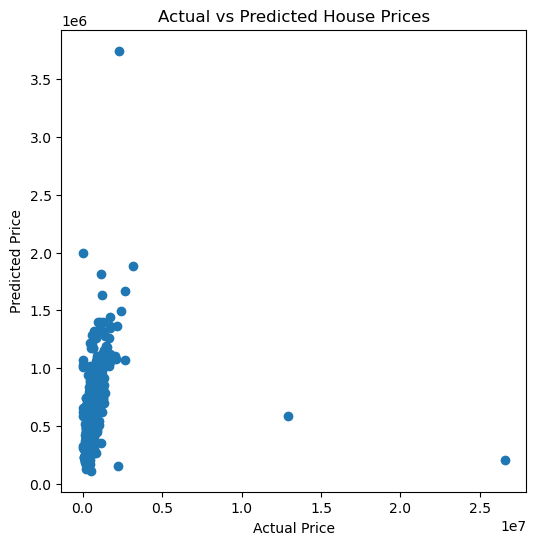

In [39]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [42]:
import joblib
import numpy as np

# Load trained model
model = joblib.load("house_price_model.pkl")

# Example house data
# Format:
# [bedrooms, bathrooms, sqft_living, sqft_lot, floors, waterfront,
#  view, condition, sqft_above, sqft_basement, yr_built, yr_renovated]

house_example = np.array([[3, 2, 1500, 5000, 1, 0, 0, 3, 1500, 0, 1995, 0]])

# Predict price
predicted_price = model.predict(house_example)

print("Predicted House Price: $", round(predicted_price[0], 2))

Predicted House Price: $ 259330.59


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
